# Do stocks quietly drift up *before* the Fed speaks? 🏦
### The pre-FOMC announcement drift — a real anomaly that quietly died once it was famous

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Run-up only?: Mixed](https://img.shields.io/badge/Run--up_only%3F-Mixed-8b949e?style=flat-square)

Here's one of the strangest facts in markets. Eight times a year the Federal Reserve announces its interest-rate decision — and the date is known **months in advance**. There's no secret. Yet for two decades, the US stock market **drifted up in the hours before** each of those announcements, earning so much that a sliver of days carried a huge chunk of the *entire* market's return.

Two economists, **Lucca and Moench**, wrote this up in a famous 2015 paper. And then something very on-brand happened: once everyone knew about it, **it stopped working**. This notebook is the story of a real edge — and how publishing it killed it.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo tests and the decay split? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** We test the broad market via **SPY** (an index ETF, so no survivorship problem) plus a 30-name survivor basket as colour. The Fed-meeting calendar is **hardcoded** from the Fed's own schedules. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pre_fomc_drift import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
if HAVE_REAL:
    PRICES, OHLC = data.load_real()
    PRICES = PRICES[PRICES.index <= ASOF]; OHLC = OHLC[OHLC.index <= ASOF]
    SPY = PRICES["SPY"].dropna()
    RET = st.daily_returns(SPY)
    MASK = data.tag_pre_fomc(RET.index, shift=0)
else:
    PRICES = OHLC = SPY = RET = MASK = None
print("real pre-FOMC cache present:", HAVE_REAL,
      "| daily returns:", (0 if RET is None else len(RET)),
      "| pre-FOMC days:", (0 if MASK is None else int(MASK.sum())))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1993-02-01', 'end': '2026-05-29', 'asof': '2026-05-31', 'years': 33.3, 'n_days': 8389, 'n_meetings': 261, 'n_pre': 260, 'frac_days': 3.1, 'fingerprint': '9687074d1493', 'ev_mean': 0.2271, 'rest_mean': 0.0422, 'ev_t0': 3.04, 'welch_t': 2.44, 'share_total': 14.7, 'placebo_p': 0.007, 'pre2012': ('pre-2012', 0.3346, 0.0279, 2.94, 27.4, 145), 'post2012': ('post-2012', 0.0914, 0.061, 0.28, 4.7, 115), 'split': '2012-01-01', 'oi': [('overnight', 0.108, 0.0303, 1.7), ('intraday', 0.1197, 0.0045, 1.78), ('daily', 0.2271, 0.0349, 2.54)], 'costs': [(0.5, 0.2271, 0.2171, 2.91), (1.0, 0.2271, 0.2071, 2.77), (2.0, 0.2271, 0.1871, 2.51)], 'shift': [('announcement-day', 0.2271, 2.44, 14.7), ('strictly prior (-1)', 0.1609, 1.4, 10.4)], 'syn': [(0.0, -0.09, 0.05), (0.4, 4.24, 0.97)]}


real pre-FOMC cache present: True | daily returns: 8389 | pre-FOMC days: 260


## The answer first

| Question | Answer |
|---|---|
| Did stocks drift up before Fed meetings? | **Yes — really.** Over 33 years, the day before each Fed decision earned **+0.227%** on average vs **+0.042%** for a normal day. Those **3% of days carried 15%** of the market's *entire* cumulative return. |
| Is it just luck? | **No.** A one-sample *t* of **3.04**, and a test that re-rolls the calendar 20,000 times at random says you'd see this by chance only **0.7%** of the time. |
| Can I trade it today? | **Not really.** After the paper came out, the effect **collapsed** — since 2012 the pre-Fed day is statistically a *normal day*. |
| Is it the 'run-up into the 2pm statement'? | **Half.** About half the gain shows up **overnight** (before the market even opens), not in the afternoon run-up the story is about. |

> The legend was **true** — and then publishing it **arbitraged it away**. A perfect little parable about market efficiency.

## 1 · The claim

> *"In the 24 hours before a scheduled Fed announcement, stocks drift **up**. Not because of any news — the meeting date is on the calendar months ahead — but the market just floats higher into the decision. Buy the day before, and you collect a chunk of the entire equity premium on a handful of days a year."*

This isn't a trader's tall tale. **Lucca & Moench (2015, Journal of Finance)** showed that since 1994 the pre-FOMC window earned a startling share of the market's total return — one of the most striking calendar effects ever documented. The puzzle: *why would a pre-scheduled, no-news event move prices at all?*

## 2 · So what?

If markets were perfectly efficient, a **known** event with **no new information** in the window shouldn't earn anything special. The pre-FOMC drift says otherwise — which made it a genuine crack in the efficient-markets story, and catnip for traders.

But two traps hide here. **(1)** Famous edges tend to **die** once they're published — everyone front-runs them until there's nothing left. **(2)** The exact *story* (a run-up into the afternoon statement) might be wrong even if the *effect* is real. We'll test both.

## 3 · How would we even know?

We hardcode the Fed's scheduled-meeting calendar — **261 meetings** from 1994 to 2026 — and tag the SPY trading session that ends just before each one. That's only **3%** of all trading days. Then:

1. **The drift.** Compare the average return on those pre-Fed days to every other day.
2. **The luck test.** Re-roll the calendar 20,000 times at random — could a random set of the same number of days have looked this good?
3. **The decay test.** Split the history at 2012 (after the paper circulated) and ask: did the edge survive being famous?
4. **The mechanism.** Split each day into its **overnight** move and its **intraday** move — is the drift really the afternoon run-up the story claims?

## 4 · The teardown — let's actually look

**First, the headline.** Average return on pre-Fed days vs every other day, full sample.

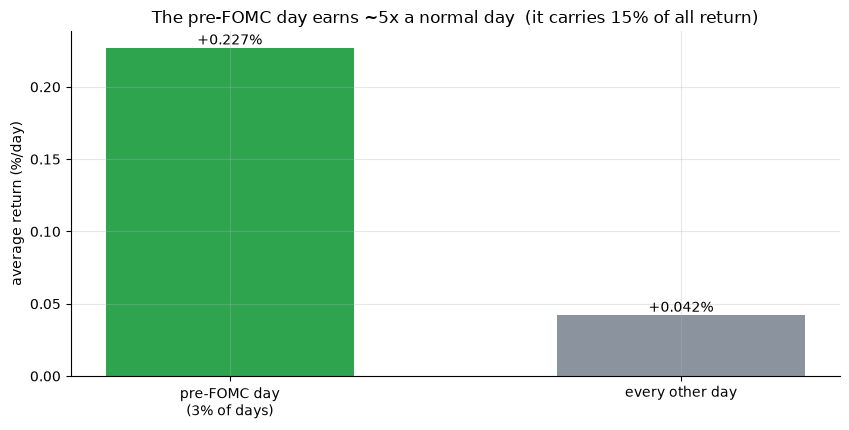

pre-FOMC mean: +0.227%/day   other-day mean: +0.042%/day   share of cumulative return on 3% of days: 15%


In [2]:
if HAVE_REAL:
    full = st.event_vs_rest(RET.values, MASK)
    ev, rest, share = full['ev_mean']*100, full['rest_mean']*100, full['share_of_total']*100
else:
    ev, rest, share = R['ev_mean'], R['rest_mean'], R['share_total']
fig, ax = plt.subplots(figsize=(8.6, 4.4))
ax.bar(['pre-FOMC day\n(3% of days)', 'every other day'], [ev, rest], color=[GREEN, GREY], width=.55)
for i,v in enumerate([ev, rest]): ax.annotate(f'{v:+.3f}%',(i,v),ha='center',va='bottom')
ax.set_ylabel('average return (%/day)')
ax.set_title(f'The pre-FOMC day earns ~5x a normal day  (it carries {share:.0f}% of all return)')
plt.tight_layout(); plt.show()
print(f'pre-FOMC mean: {ev:+.3f}%/day   other-day mean: {rest:+.3f}%/day   '
      f'share of cumulative return on 3% of days: {share:.0f}%')

There it is. The pre-Fed day earns **+0.227%** — roughly **five times** a normal day — and those **3%** of sessions carry **15%** of SPY's *entire* cumulative return since 1993. That's a real, large effect.

**But did it survive being famous?** Here's the same comparison, split before and after 2012 (the paper circulated in 2011, published 2015). Watch the right-hand pair.

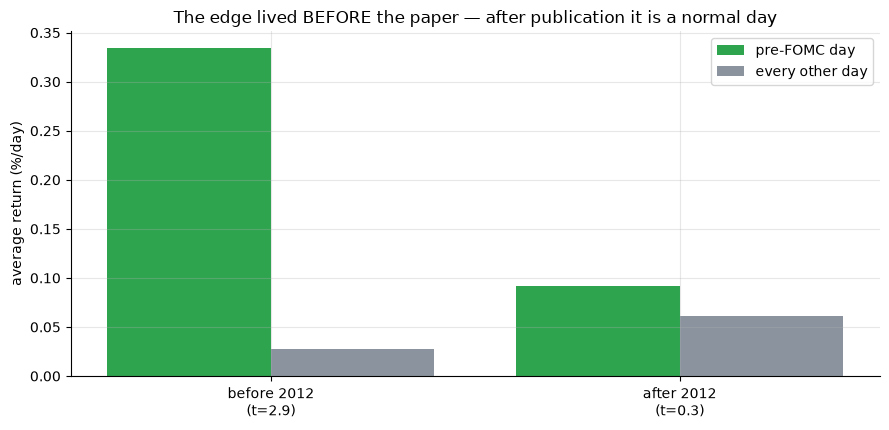

pre-2012:  pre-FOMC +0.335% vs other +0.028%  (Welch t=2.94)
post-2012: pre-FOMC +0.091% vs other +0.061%  (Welch t=0.28)


In [3]:
if HAVE_REAL:
    sp = st.split_summary(RET, MASK)
    pre_ev, pre_rest = sp['pre']['ev_mean']*100, sp['pre']['rest_mean']*100
    po_ev, po_rest = sp['post']['ev_mean']*100, sp['post']['rest_mean']*100
    pre_t, po_t = sp['pre']['welch_t'], sp['post']['welch_t']
else:
    pre_ev, pre_rest, pre_t = R['pre2012'][1], R['pre2012'][2], R['pre2012'][3]
    po_ev, po_rest, po_t = R['post2012'][1], R['post2012'][2], R['post2012'][3]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, [pre_ev, po_ev], .4, color=GREEN, label='pre-FOMC day')
ax.bar(x+.2, [pre_rest, po_rest], .4, color=GREY, label='every other day')
ax.set_xticks(x); ax.set_xticklabels([f'before 2012\n(t={pre_t:.1f})', f'after 2012\n(t={po_t:.1f})'])
ax.set_ylabel('average return (%/day)'); ax.legend()
ax.set_title('The edge lived BEFORE the paper — after publication it is a normal day')
plt.tight_layout(); plt.show()
print(f'pre-2012:  pre-FOMC {pre_ev:+.3f}% vs other {pre_rest:+.3f}%  (Welch t={pre_t:.2f})')
print(f'post-2012: pre-FOMC {po_ev:+.3f}% vs other {po_rest:+.3f}%  (Welch t={po_t:.2f})')

This is the punchline. Before 2012 the pre-Fed day earned **+0.335%** at a convincing *t* of **2.9**. After 2012 it's **+0.091%** vs **+0.061%** for a normal day — a *t* of just **0.28**, i.e. **nothing**. The edge didn't fade gently; it switched off once the paper was out.

**And the mechanism?** The story is "stocks run up into the 2:15pm statement" — that would put the gain in the **intraday** session. Let's split each day into its overnight move (before the open) and its intraday move (open to close).

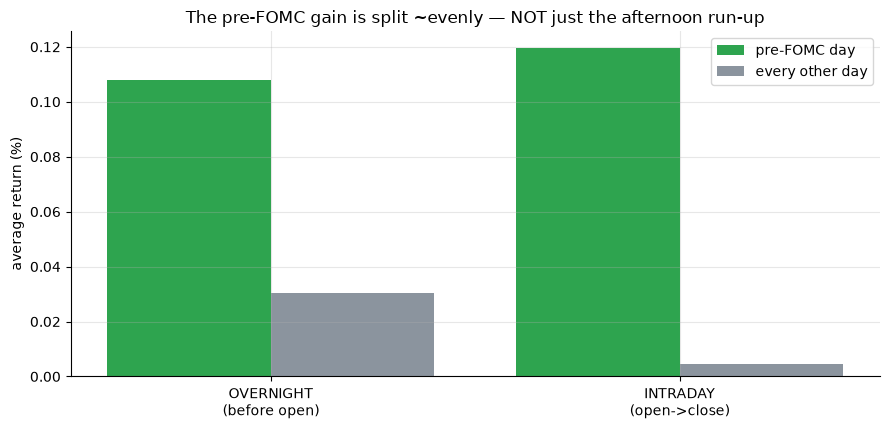

overnight: pre-FOMC +0.108% vs other +0.030%
intraday:  pre-FOMC +0.120% vs other +0.004%


In [4]:
if HAVE_REAL:
    oi = st.overnight_intraday(OHLC); oi = oi[oi.index.isin(RET.index)]
    m2 = data.tag_pre_fomc(oi.index, shift=0)
    vals = [st.event_vs_rest(oi[c].values, m2)['ev_mean']*100 for c in ('overnight','intraday')]
    rests = [st.event_vs_rest(oi[c].values, m2)['rest_mean']*100 for c in ('overnight','intraday')]
else:
    vals = [R['oi'][0][1], R['oi'][1][1]]; rests = [R['oi'][0][2], R['oi'][1][2]]
x = np.arange(2)
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.bar(x-.2, vals, .4, color=GREEN, label='pre-FOMC day')
ax.bar(x+.2, rests, .4, color=GREY, label='every other day')
ax.set_xticks(x); ax.set_xticklabels(['OVERNIGHT\n(before open)', 'INTRADAY\n(open->close)'])
ax.set_ylabel('average return (%)'); ax.legend()
ax.set_title('The pre-FOMC gain is split ~evenly — NOT just the afternoon run-up')
plt.tight_layout(); plt.show()
print(f'overnight: pre-FOMC {vals[0]:+.3f}% vs other {rests[0]:+.3f}%')
print(f'intraday:  pre-FOMC {vals[1]:+.3f}% vs other {rests[1]:+.3f}%')

The famous story is only **half right**. Yes, the intraday session is elevated (**+0.120%** vs +0.004%) — but so is the **overnight** gap (**+0.108%** vs +0.030%), before the market even opens. A good chunk of the pre-FOMC drift arrives in your sleep, not in the 2pm run-up.

## 5 · The verdict

- **Signal — Real.** The pre-FOMC day earned **+0.227%/day** (*t* = 3.04), and 3% of days carried 15% of all return. A genuine anomaly — rare among the legends we test.
- **Tradability — Fragile.** It **decayed to nothing** after publication (post-2012 *t* = 0.28). Real in the archive, dead in the present.
- **"It's the afternoon run-up"? — Mixed.** Half the gain is **overnight**, before the open. The clean run-up-into-the-statement story is only half the truth.

## 6 · Could you actually trade it? — costs aren't the problem, decay is

SPY is one of the cheapest things on earth to trade, so a calendar rule that's only in the market on pre-Fed days pays almost nothing in costs. The catch isn't costs — it's that you'd be trading a **dead** signal. Here's the gross-vs-net (it barely moves), then remember the post-2012 *t* was 0.28.

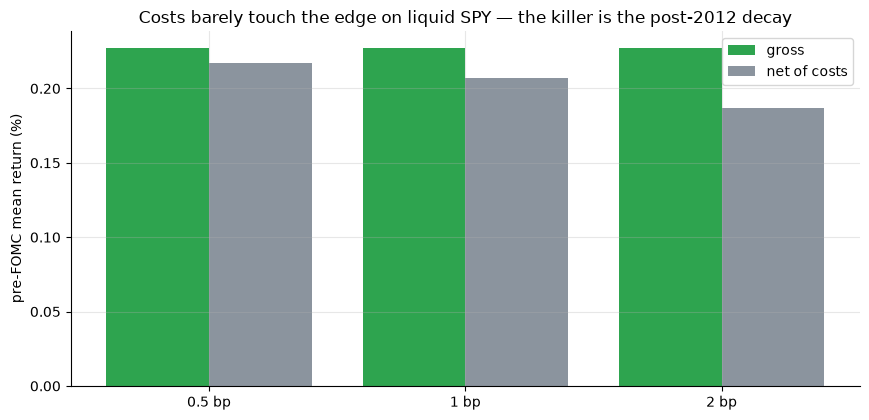

gross vs net at 1bp: +0.227% -> +0.207% | but post-2012 t = 0.28 (dead)


In [5]:
if HAVE_REAL:
    rows = [st.timing_strategy(RET.values, MASK, cost_bps=cb) for cb in (0.5, 1.0, 2.0)]
    g = [r['gross_mean']*100 for r in rows]; nv = [r['net_mean']*100 for r in rows]
else:
    g = [c[1] for c in R['costs']]; nv = [c[2] for c in R['costs']]
x = np.arange(3)
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x-.2, g, .4, color=GREEN, label='gross')
ax.bar(x+.2, nv, .4, color=GREY, label='net of costs')
ax.set_xticks(x); ax.set_xticklabels(['0.5 bp','1 bp','2 bp'])
ax.set_ylabel('pre-FOMC mean return (%)'); ax.legend()
ax.set_title('Costs barely touch the edge on liquid SPY — the killer is the post-2012 decay')
plt.tight_layout(); plt.show()
print('gross vs net at 1bp:', f'{g[1]:+.3f}% -> {nv[1]:+.3f}%', '| but post-2012 t = 0.28 (dead)')

At a realistic 1 bp the edge goes from **+0.227%** gross to **+0.207%** net — basically untouched. The reason you still can't deploy it is the decay: you'd be timing a signal that stopped paying a decade ago.

## 7 · Going further 🚪

- **The decay is the lesson.** This is the cleanest example in the whole desk of *McLean-Pontiff* — a real, published anomaly arbitraged away once everyone knew. Edges that make headlines are exactly the ones most likely to vanish.
- **The mechanism matters.** "Stocks run up into the 2pm statement" is a tidy story, but the data says half the move is overnight. Tidy stories about *why* an effect exists are often wrong even when the effect is right.
- **Replication.** This study re-derives [Study 67 — Fed-Drift](../../67-fed-drift/) on an independent hardcoded calendar and agrees — a real edge, fragile to harvest.

*Think the pre-FOMC day still pays? Show a **post-2012** Welch *t* above 2 on honest data — then we'll talk.*